
# Week 04 – Image Processing Assignment

## Topics Covered
- Power Law Transformation (Gamma Correction)
- Image Negative
- Gamma Curves Analysis
- Intensity Range Mapping
- Practical Image Enhancement Techniques

**Student Name:** Muhammadjon Parpiyev  
**Student ID:** 230274  
**Course:** DIP  
**Instructor:** B.Kiani  
**Date:** 21 February 2026

---

## Submission Rules
- All solutions must be implemented in code.
- Output images must be clearly displayed.
- Code must be clean and well-structured.
- No theoretical explanation sections required.

---



# Part 1 – Power Law Transformation (Gamma Correction)

### Challenge 1.1
Implement a function `gamma_correction(image, gamma)` from scratch.

Requirements:
- Normalize image to [0,1]
- Apply power-law transformation
- Convert back to uint8
- Display original and corrected image side by side

---


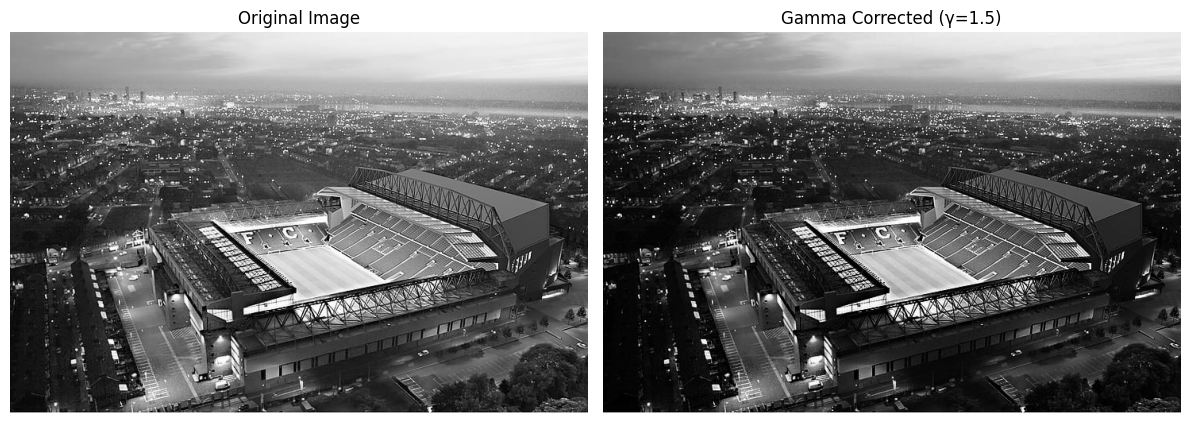

In [10]:
# Implement gamma_correction function here
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def gamma_correction(image, gamma):
    """
    Apply gamma correction to an image.
    
    Parameters:
    - image: Input image (numpy array)
    - gamma: Gamma value for correction
    
    Returns:
    - Corrected image (numpy array, uint8)
    """
    # Normalize image to [0, 1]
    normalized = image.astype(np.float32) / 255.0
    
    # Apply power-law transformation
    corrected = np.power(normalized, gamma)
    
    # Convert back to uint8
    corrected_uint8 = (corrected * 255).astype(np.uint8)
    
    return corrected_uint8

# Load the real image from file
img = np.array(Image.open('anfield.jpg').convert('L'))

# Apply gamma correction
gamma_value = 1.5
corrected_img = gamma_correction(img, gamma_value)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(corrected_img, cmap='gray')
axes[1].set_title(f'Gamma Corrected (γ={gamma_value})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 1.2 – Gamma Curve Analysis

1. Generate intensity values r in range [0,1].
2. Plot gamma curves for at least 5 different gamma values.
3. Ensure all curves appear in one plot.

---


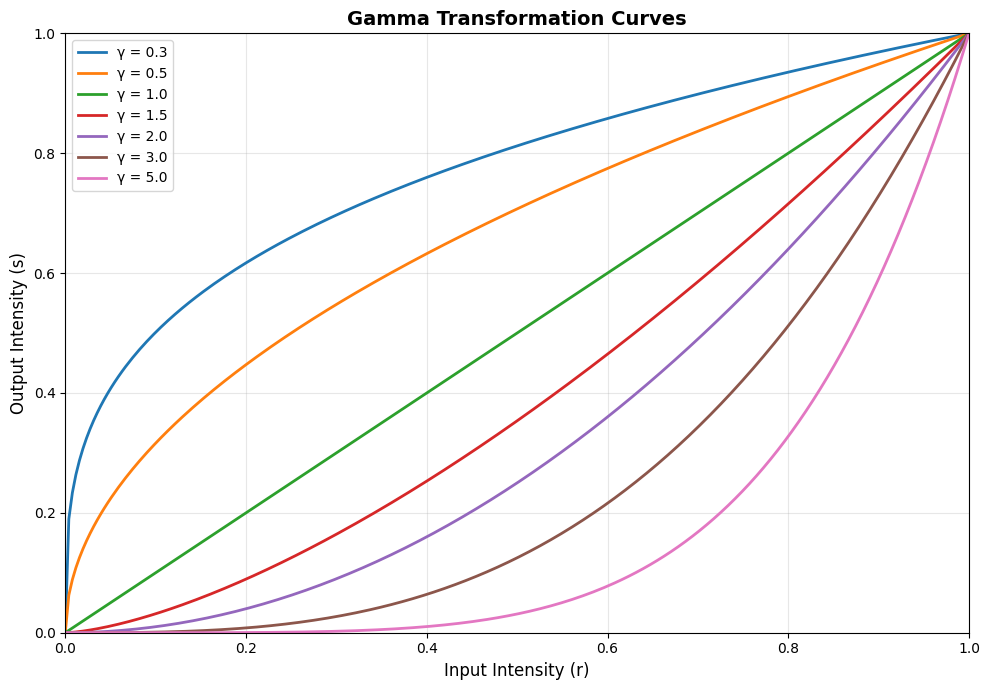

In [2]:
# Plot gamma curves here
import numpy as np
import matplotlib.pyplot as plt

# Generate intensity values in range [0, 1]
r = np.linspace(0, 1, 256)

# Define gamma values
gamma_values = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

# Plot gamma curves
plt.figure(figsize=(10, 7))

for gamma in gamma_values:
    s = np.power(r, gamma)
    plt.plot(r, s, label=f'γ = {gamma}', linewidth=2)

plt.xlabel('Input Intensity (r)', fontsize=12)
plt.ylabel('Output Intensity (s)', fontsize=12)
plt.title('Gamma Transformation Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


### Challenge 1.3 – Comparative Study

Apply gamma values:
- 0.5
- 1.0
- 2.0

Display results in a structured layout.
Add titles clearly indicating gamma value.

---


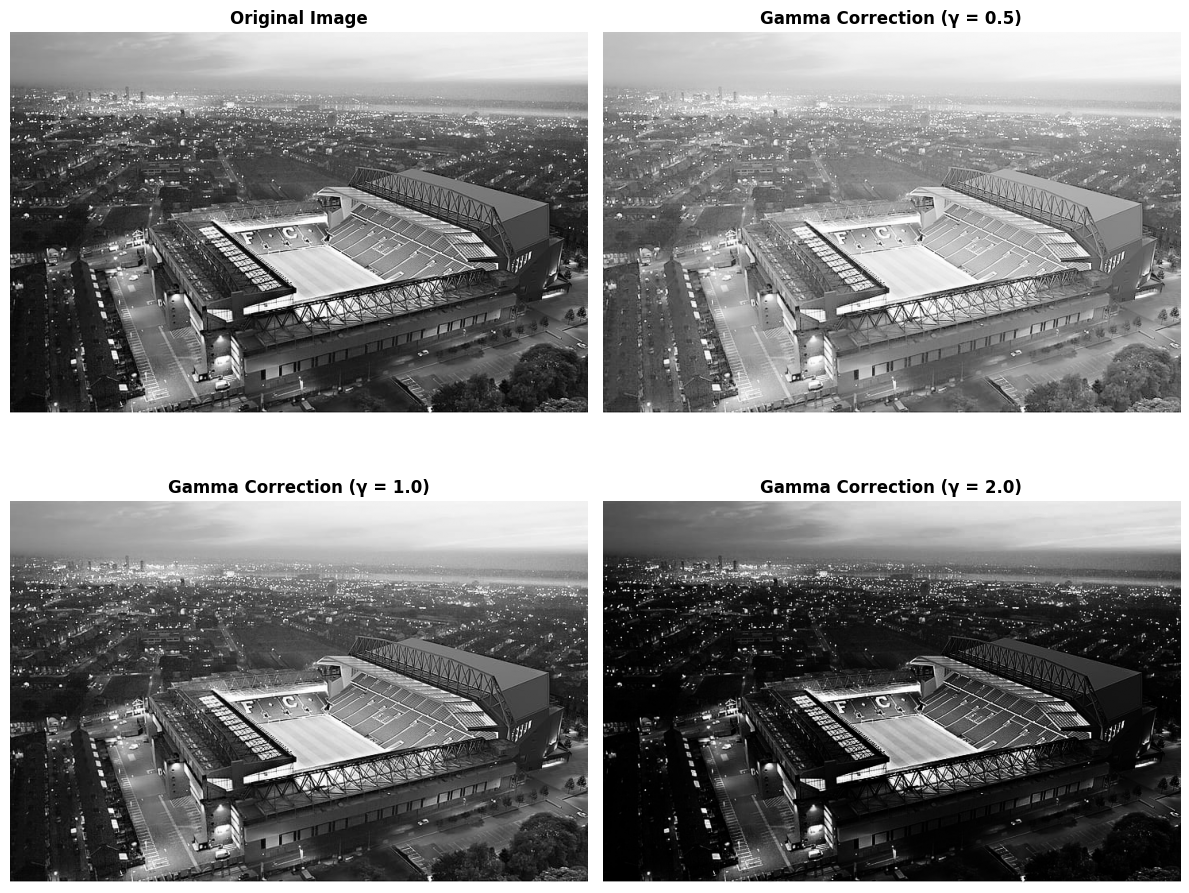

In [11]:
# Comparative gamma correction implementation
import numpy as np
import matplotlib.pyplot as plt

# Define gamma values for comparison
gammas = [0.5, 1.0, 2.0]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Display original image
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Apply and display gamma corrections
for idx, gamma in enumerate(gammas):
    row = (idx + 1) // 2
    col = (idx + 1) % 2
    
    corrected = gamma_correction(img, gamma)
    axes[row, col].imshow(corrected, cmap='gray')
    axes[row, col].set_title(f'Gamma Correction (γ = {gamma})', fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


# Part 2 – Basic Intensity Transformations

### Challenge 2.1 – Image Negative

Create an image negative function without using built-in shortcuts.

Formula must be implemented manually.

---


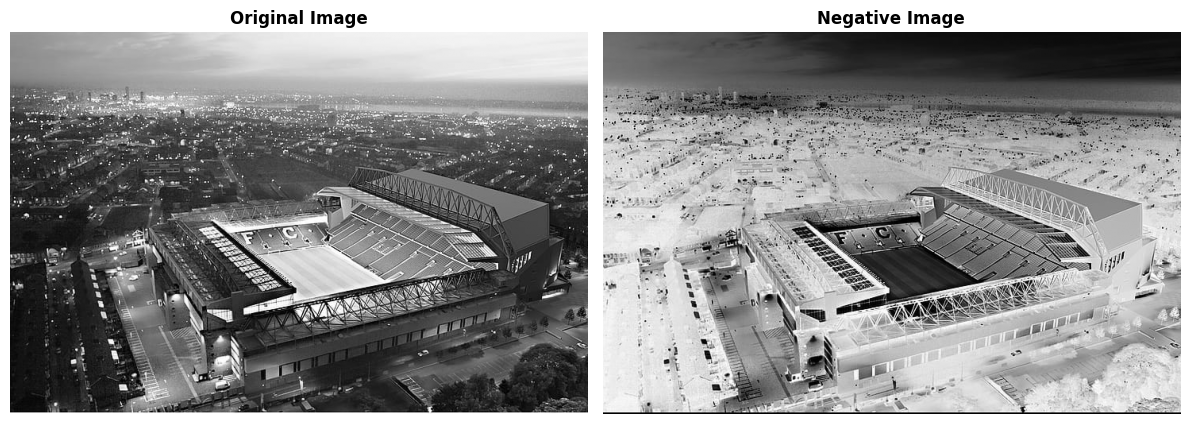

In [12]:
# Implement image negative transformation
import numpy as np
import matplotlib.pyplot as plt

def image_negative(image):
    """
    Create negative of an image using manual formula.
    
    Parameters:
    - image: Input image (numpy array)
    
    Returns:
    - Negative image (numpy array)
    """
    # For 8-bit image: s = L - 1 - r, where L = 256
    negative = 255 - image
    
    return negative

# Apply negative transformation
negative_img = image_negative(img)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(negative_img, cmap='gray')
axes[1].set_title('Negative Image', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 2.2 – Intensity Range Mapping

Set pixel intensity range [A, B] to white (255).

Requirements:
- Accept A and B as parameters.
- Leave other pixels unchanged.
- Display before and after.

---


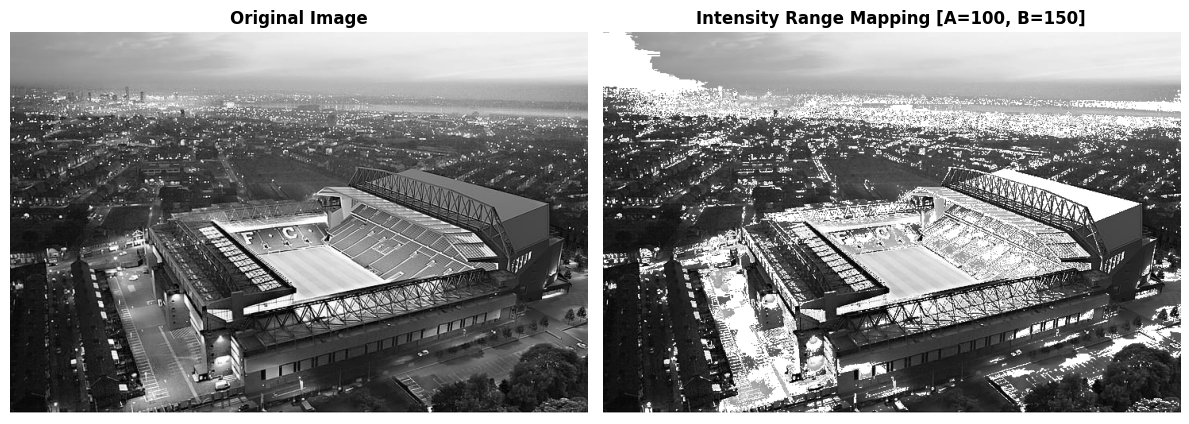

In [13]:
# Implement intensity range mapping
import numpy as np
import matplotlib.pyplot as plt

def intensity_range_mapping(image, A, B):
    """
    Map intensity range [A, B] to white (255), leave others unchanged.
    
    Parameters:
    - image: Input image (numpy array)
    - A: Lower bound of intensity range
    - B: Upper bound of intensity range
    
    Returns:
    - Mapped image (numpy array)
    """
    # Create a copy of the image
    mapped = image.copy()
    
    # Set pixels in range [A, B] to white (255)
    mask = (mapped >= A) & (mapped <= B)
    mapped[mask] = 255
    
    return mapped

# Apply intensity range mapping
A, B = 100, 150
mapped_img = intensity_range_mapping(img, A, B)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mapped_img, cmap='gray')
axes[1].set_title(f'Intensity Range Mapping [A={A}, B={B}]', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Challenge 2.3 – Integrated Enhancement

Create a pipeline that:
1. Reads image
2. Applies gamma correction
3. Applies intensity mapping
4. Displays final enhanced image

---


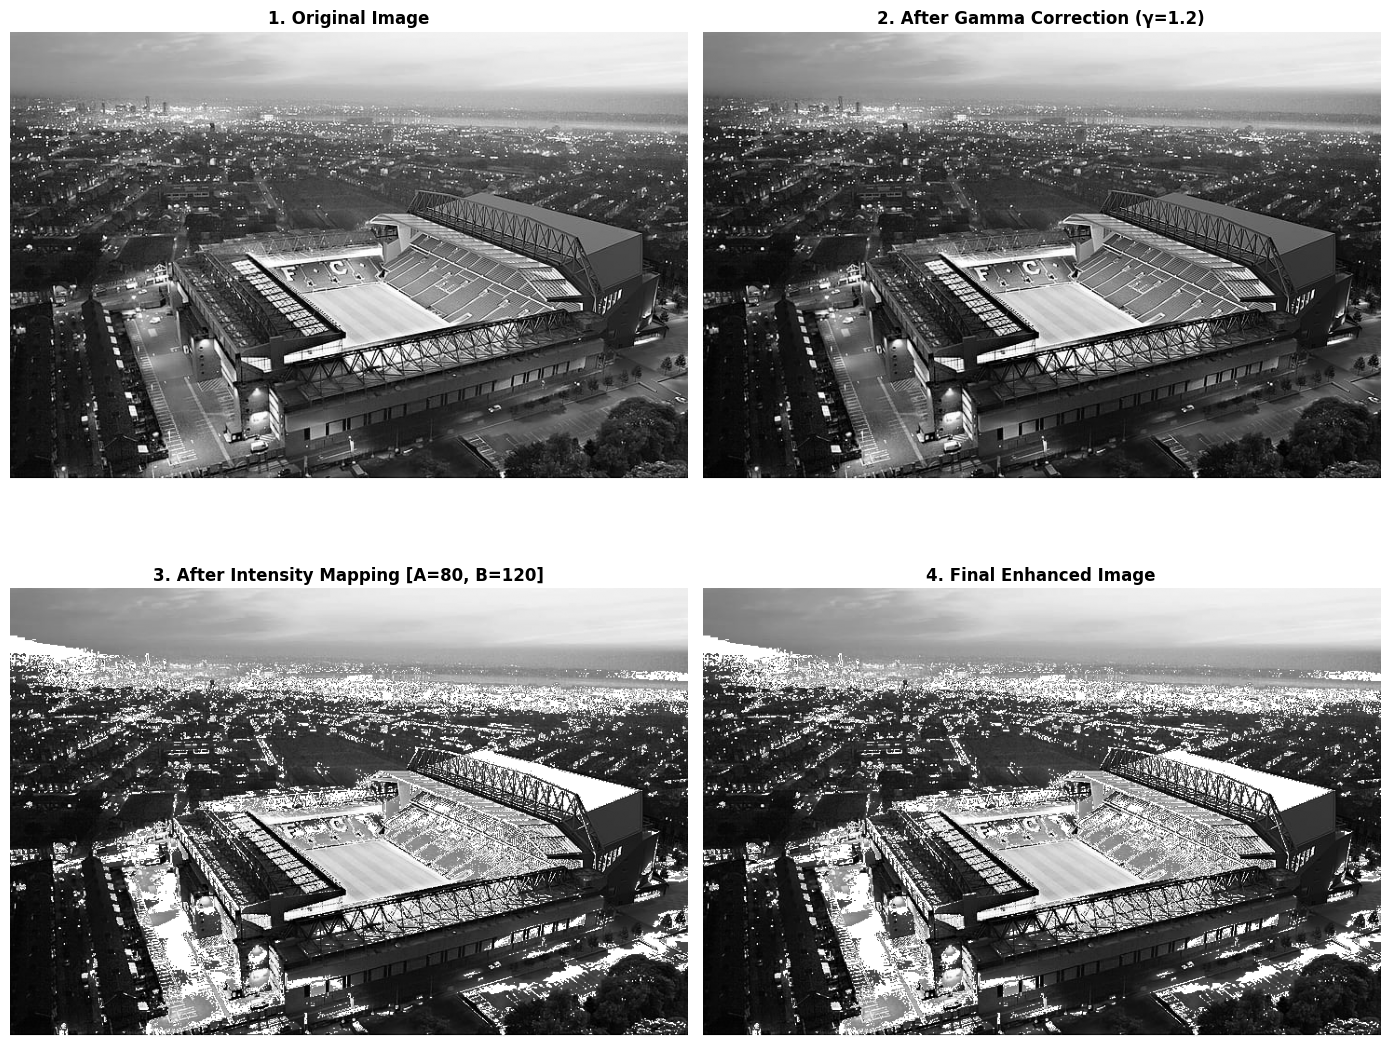

In [14]:
# Build full enhancement pipeline
import numpy as np
import matplotlib.pyplot as plt

def enhancement_pipeline(image_path, gamma, A, B):
    """
    Complete image enhancement pipeline.
    
    Steps:
    1. Read image
    2. Apply gamma correction
    3. Apply intensity mapping
    4. Display final enhanced image
    
    Parameters:
    - image_path: Path to input image
    - gamma: Gamma value for correction
    - A, B: Intensity range for mapping
    """
    # Step 1: Read image
    image = np.array(Image.open(image_path).convert('L'))
    
    # Step 2: Apply gamma correction
    gamma_corrected = gamma_correction(image, gamma)
    
    # Step 3: Apply intensity mapping
    final_enhanced = intensity_range_mapping(gamma_corrected, A, B)
    
    # Step 4: Display results
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('1. Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gamma_corrected, cmap='gray')
    axes[0, 1].set_title(f'2. After Gamma Correction (γ={gamma})', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(final_enhanced, cmap='gray')
    axes[1, 0].set_title(f'3. After Intensity Mapping [A={A}, B={B}]', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(final_enhanced, cmap='gray')
    axes[1, 1].set_title('4. Final Enhanced Image', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return final_enhanced

# Run the enhancement pipeline
enhanced_image = enhancement_pipeline("anfield.jpg", gamma=1.2, A=80, B=120)


# Part 3 – Advanced Optimization Challenge

### Challenge 3.1 – Performance & Robustness

Improve your functions by:

- Adding input validation
- Handling grayscale and RGB images
- Avoiding redundant computations
- Structuring reusable functions

---

### Final Task

Create one clean final script that performs:
- Gamma analysis
- Negative transformation
- Intensity mapping
- Final comparison visualization

---


In [18]:
# Final optimized solution
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

class ImageProcessor:
    """Optimized and robust image processing class."""
    
    @staticmethod
    def validate_image(image):
        """Validate input image."""
        if not isinstance(image, np.ndarray):
            raise TypeError("Image must be a numpy array")
        if image.size == 0:
            raise ValueError("Image is empty")
        return True
    
    @staticmethod
    def gamma_correction(image, gamma):
        """
        Apply gamma correction with validation.
        Handles both grayscale and RGB images.
        """
        ImageProcessor.validate_image(image)
        
        if gamma <= 0:
            raise ValueError("Gamma must be positive")
        
        # Normalize to [0, 1]
        normalized = image.astype(np.float32) / 255.0
        
        # Apply power-law transformation
        corrected = np.power(normalized, gamma)
        
        # Convert back to uint8
        return (corrected * 255).astype(np.uint8)
    
    @staticmethod
    def image_negative(image):
        """Create image negative with validation."""
        ImageProcessor.validate_image(image)
        return 255 - image
    
    @staticmethod
    def intensity_range_mapping(image, A, B):
        """
        Map intensity range [A, B] to white with validation.
        """
        ImageProcessor.validate_image(image)
        
        if A > B:
            raise ValueError("A must be less than or equal to B")
        if A < 0 or B > 255:
            raise ValueError("A and B must be in range [0, 255]")
        
        mapped = image.copy()
        mask = (mapped >= A) & (mapped <= B)
        mapped[mask] = 255
        
        return mapped
    
    @staticmethod
    def plot_gamma_curves(gamma_values):
        """Plot gamma transformation curves."""
        r = np.linspace(0, 1, 256)
        
        plt.figure(figsize=(10, 7))
        for gamma in gamma_values:
            s = np.power(r, gamma)
            plt.plot(r, s, label=f'γ = {gamma}', linewidth=2)
        
        plt.xlabel('Input Intensity (r)', fontsize=12)
        plt.ylabel('Output Intensity (s)', fontsize=12)
        plt.title('Gamma Transformation Curves', fontsize=14, fontweight='bold')
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.tight_layout()
        plt.show()

# Load image
img = np.array(Image.open("sample_image.jpg").convert('L'))

# Create processor instance
processor = ImageProcessor()

# 1. Gamma Analysis
print("=" * 60)
print("1. GAMMA ANALYSIS")
print("=" * 60)
processor.plot_gamma_curves([0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])

# 2. Negative Transformation
print("\n" + "=" * 60)
print("2. NEGATIVE TRANSFORMATION")
print("=" * 60)
negative_img = processor.image_negative(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(negative_img, cmap='gray')
axes[1].set_title('Negative', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 3. Intensity Mapping
print("\n" + "=" * 60)
print("3. INTENSITY MAPPING")
print("=" * 60)
mapped_img = processor.intensity_range_mapping(img, 100, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(mapped_img, cmap='gray')
axes[1].set_title('Intensity Mapped [100, 150]', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 4. Final Comparison Visualization
print("\n" + "=" * 60)
print("4. FINAL COMPARISON VISUALIZATION")
print("=" * 60)

gamma_corrected = processor.gamma_correction(img, 1.5)
gamma_mapped = processor.intensity_range_mapping(gamma_corrected, 80, 120)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original, Gamma, Negative
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(gamma_corrected, cmap='gray')
axes[0, 1].set_title('Gamma Corrected (γ=1.5)', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(negative_img, cmap='gray')
axes[0, 2].set_title('Negative', fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Intensity Mapped, Combined, Final
axes[1, 0].imshow(mapped_img, cmap='gray')
axes[1, 0].set_title('Intensity Mapped', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(gamma_mapped, cmap='gray')
axes[1, 1].set_title('Gamma + Intensity Mapping', fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(gamma_mapped, cmap='gray')
axes[1, 2].set_title('Enhanced Final Result', fontsize=11, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PROCESSING COMPLETE!")
print("=" * 60)

FileNotFoundError: [Errno 2] No such file or directory: 'sample_image.jpg'